In [14]:
#load /Users/k23030440/Library/CloudStorage/OneDrive-King\'sCollegeLondon/PhD/Year_two/Aim\ 1/perturbs/assignmentsGonadotrophs.gata2_ckoGATA2_CKO_GATA2_CKO_vs_Control_limma3v3.csv
import pandas as pd
gata2_hits = pd.read_csv('/Users/k23030440/Library/CloudStorage/OneDrive-King\'sCollegeLondon/PhD/Year_two/Aim 1/perturbs/assignmentsGonadotrophs.gata2_ckoGATA2_CKO_GATA2_CKO_vs_Control_limma3v3.csv')
#rename
gata2_hits = gata2_hits.rename(columns={'Unnamed: 0': 'gene'})
#keep where adj.P.Val < 0.05
gata2_hits_sig = gata2_hits[gata2_hits['adj.P.Val'] < 0.05]

In [4]:
pip install adjusttext

Note: you may need to restart the kernel to use updated packages.


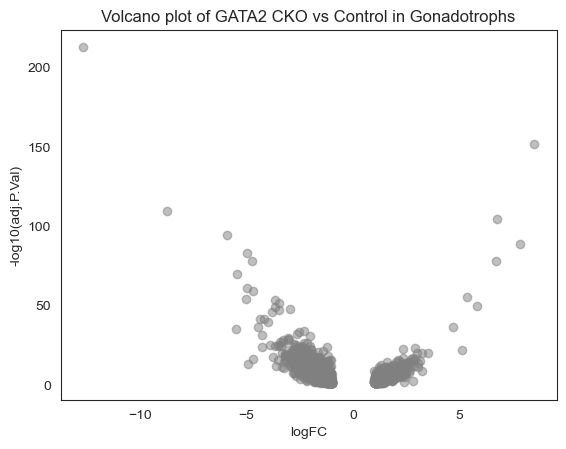

In [25]:
#keep for gonadotrophs /Users/k23030440/epitome_code/epitome/data/sex_dimorphism/v_0.02/sexually_dimorphic_genes.csv
gonado_dimorphic_genes = pd.read_csv('/Users/k23030440/epitome_code/epitome/data/sex_dimorphism/v_0.02/sexually_dimorphic_genes.csv')
#keep only where cell_type == Gonadotrophs
gonado_dimorphic_genes = gonado_dimorphic_genes[gonado_dimorphic_genes['cell_type'] == 'Gonadotrophs']
#make volcano scatter plot 
import matplotlib.pyplot as plt
import numpy as np
plt.scatter(gonado_dimorphic_genes['logFC'], -np.log10(gonado_dimorphic_genes['adj.P.Val']), color='grey', alpha=0.5)
plt.xlabel('logFC')
plt.ylabel('-log10(adj.P.Val)')
plt.title('Volcano plot of GATA2 CKO vs Control in Gonadotrophs')
plt.show()

In [26]:
gata2_hits_sig 

,gene,logFC_gata2,AveExpr,t,P.Value,adj.P.Val_gata2,B,genes,color,logFC_gonado,adj.P.Val_gonado
0,Pcsk1,-2.043710,6.669942,-12.590105,2.415063e-12,3.720646e-08,17.835075,Pcsk1,#63B3ED,1.114655,1.325100e-04
1,Grem1,-5.170766,1.179786,-9.929094,3.560640e-10,2.742761e-06,9.174283,Grem1,#63B3ED,5.174744,2.823000e-22
2,Serpine2,-2.307158,5.512935,-9.423532,1.011460e-09,5.194183e-06,12.219129,Serpine2,#63B3ED,1.958881,1.426495e-12
3,Prkg1,-2.180835,7.237988,-8.633947,5.518600e-09,2.125489e-05,10.657660,Prkg1,#63B3ED,NaN,NaN
4,Gm30382,2.280855,3.066923,8.163537,1.576996e-08,4.859041e-05,9.368798,Gm30382,#FFA500,NaN,NaN
5,Phex,-2.366336,2.348072,-7.495621,7.364747e-08,1.891022e-04,7.679857,Phex,#63B3ED,1.053342,8.171055e-04
6,Gm42439,1.064802,7.622166,7.119055,1.801496e-07,3.964836e-04,7.313260,Gm42439,#FFA500,NaN,NaN
7,Serpinb1a,-2.412216,1.099702,-6.871974,3.271396e-07,6.299891e-04,6.065897,Serpinb1a,#63B3ED,3.220624,2.530529e-12
8,Gm37350,-3.047575,-0.082555,-6.675087,5.290521e-07,8.856780e-04,4.160483,Gm37350,#63B3ED,1.752176,5.936311e-04
9,Gm5149,2.077420,0.659395,6.607149,6.251658e-07,8.856780e-04,5.173868,Gm5149,#FFA500,NaN,NaN


Contingency table:
gonado_dir  up  down
gata2_dir           
up          18     2
down         1     5

Fisher's exact test:
Odds ratio = 45.000
P-value = 1.763e-03
0 [0.86595933 0.81761416]
2 [-0.28129834  0.94771186]
0 [0.6273181  0.28812055]
2 [ 0.49894611 -0.17362425]


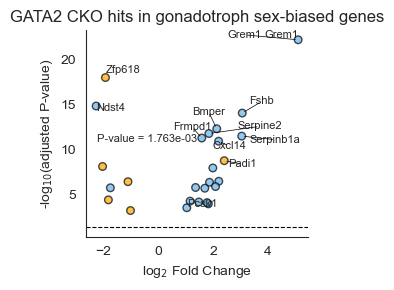

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

# -----------------------------
# Filter significant genes
# -----------------------------
gata2_hits_sig = gata2_hits[gata2_hits['adj.P.Val'] < 0.05].copy()

# Assign direction-based colors (Nature-friendly palette)
gata2_hits_sig['color'] = "#4D4D4D"  # default grey
gata2_hits_sig.loc[gata2_hits_sig['logFC'] > 0, 'color'] = "#FFA500"

gata2_hits_sig.loc[gata2_hits_sig['logFC'] < 0, 'color'] =  "#63B3ED"
# Merge with gonadal dimorphic genes
gata2_hits_sig = pd.merge(
    gata2_hits_sig,
    gonado_dimorphic_genes[['gene', 'logFC', 'adj.P.Val']],
    on='gene',
    how='left',
    suffixes=('_gata2', '_gonado')
)



from scipy.stats import fisher_exact
import numpy as np
import pandas as pd

# Keep only genes present in both datasets and significant in GATA2
df = gata2_hits_sig.dropna(subset=['logFC_gonado']).copy()

# Define direction
df['gata2_dir'] = np.where(df['logFC_gata2'] < 0, 'up', 'down')
df['gonado_dir'] = np.where(df['logFC_gonado'] > 0, 'up', 'down')

# Build contingency table
contingency = pd.crosstab(df['gata2_dir'], df['gonado_dir'])

# Ensure proper ordering
contingency = contingency.reindex(index=['up','down'], columns=['up','down'], fill_value=0)

# Fisher’s exact test
oddsratio, pvalue = fisher_exact(contingency)

print("Contingency table:")
print(contingency)
print(f"\nFisher's exact test:")
print(f"Odds ratio = {oddsratio:.3f}")
print(f"P-value = {pvalue:.3e}")




# -----------------------------
# Plot
# -----------------------------
sns.set_style("white")
plt.figure(figsize=(3,3))

x = gata2_hits_sig['logFC_gonado']
y = -np.log10(gata2_hits_sig['adj.P.Val_gonado'])

plt.scatter(
    x,
    y,
    c=gata2_hits_sig['color'],
    s=30,
    alpha=0.7,
    edgecolor='black'
)

# Significance threshold line
plt.axhline(-np.log10(0.05), color='black', linestyle='--', linewidth=0.8)

# Labels
plt.xlabel("log$_2$ Fold Change", fontsize=10)
plt.ylabel("-log$_{10}$(adjusted P-value)", fontsize=10)
plt.title("GATA2 CKO hits in gonadotroph sex-biased genes", fontsize=12)
top10 = (
    gata2_hits_sig
    .dropna(subset=['adj.P.Val_gonado'])
    .sort_values('adj.P.Val_gonado')
    .head(10)
)

texts = []
#also highlight Grem1, Pitx1 Pcsk1
highlight_genes = ['Grem1', 'Pitx1', 'Pcsk1']
for gene in highlight_genes:
    if gene in gata2_hits_sig['gene'].values:
        row = gata2_hits_sig[gata2_hits_sig['gene'] == gene].iloc[0]
        texts.append(
            plt.text(
                row['logFC_gonado'],
                -np.log10(row['adj.P.Val_gonado']),
                row['gene'],
                fontsize=8,
            )
        )
for _, row in top10.iterrows():
    texts.append(
        plt.text(
            row['logFC_gonado'],
            -np.log10(row['adj.P.Val_gonado']),
            row['gene'],
            fontsize=8
        )
    )

#add pval
plt.text(0.05, 0.5, f"P-value = {pvalue:.3e}", transform=plt.gca().transAxes, fontsize=8, verticalalignment='top')


adjust_text(
    texts,
    arrowprops=dict(arrowstyle='-', color='black', lw=0.5),
    force_points=0.3,
    force_text=0.5
)
#svg and png to /Users/k23030440/Library/CloudStorage/OneDrive-King\'sCollegeLondon/PhD/Year_two/Aim\ 1/DE
plt.savefig('/Users/k23030440/Library/CloudStorage/OneDrive-King\'sCollegeLondon/PhD/Year_two/Aim 1/DE/gata2_volcano_gonadotrophs.png', dpi=300, bbox_inches='tight')
plt.savefig('/Users/k23030440/Library/CloudStorage/OneDrive-King\'sCollegeLondon/PhD/Year_two/Aim 1/DE/gata2_volcano_gonadotrophs.svg', bbox_inches='tight')
# Clean up spines
sns.despine()
plt.tight_layout()
plt.show()
